Loading the Data set and inspect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('creditcard.csv')


In [3]:
print("Dataset shape:", df.shape)


Dataset shape: (29142, 31)


In [4]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26      

In [5]:
print("\nColumn info:")
print(df.info())


Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29142 entries, 0 to 29141
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    29142 non-null  int64  
 1   V1      29142 non-null  float64
 2   V2      29142 non-null  float64
 3   V3      29142 non-null  float64
 4   V4      29142 non-null  float64
 5   V5      29142 non-null  float64
 6   V6      29142 non-null  float64
 7   V7      29142 non-null  float64
 8   V8      29141 non-null  float64
 9   V9      29141 non-null  float64
 10  V10     29141 non-null  float64
 11  V11     29141 non-null  float64
 12  V12     29141 non-null  float64
 13  V13     29141 non-null  float64
 14  V14     29141 non-null  float64
 15  V15     29141 non-null  float64
 16  V16     29141 non-null  float64
 17  V17     29141 non-null  float64
 18  V18     29141 non-null  float64
 19  V19     29141 non-null  float64
 20  V20     29141 non-null  float64
 21  V21     29141 non-nul

Checking data quality

In [6]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [7]:
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 119


In [8]:
print("\nUnique values in Class column:", df['Class'].unique())


Unique values in Class column: [ 0.  1. nan]


In [9]:
print("\nClass value counts:")
print(df['Class'].value_counts())


Class value counts:
Class
0.0    29048
1.0       93
Name: count, dtype: int64


Visualising the class imbalance

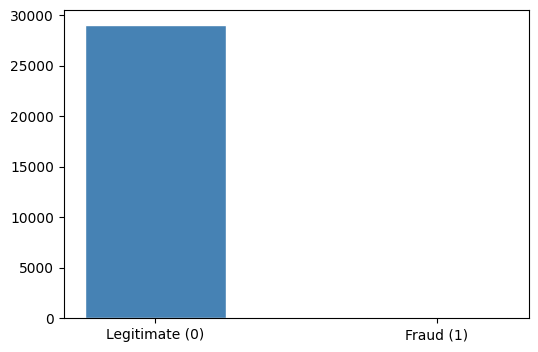

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['Class'].value_counts()
bars = ax.bar(['Legitimate (0)', 'Fraud (1)'],
              counts.values,
              color=['steelblue', 'crimson'],
              edgecolor='white', width=0.5)

In [11]:
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2000,
            f'{count:,}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Class Distribution: Legitimate vs Fraudulent Transactions',
             fontsize=13, pad=12)
ax.set_ylabel('Number of Transactions')
ax.set_ylim(0, 320000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print(f"\nFraud rate: {counts[1]/counts.sum()*100:.3f}%")

<Figure size 640x480 with 0 Axes>


Fraud rate: 0.319%


Remove duplicates

In [12]:
df = df.drop_duplicates()

# Confirm new shape
print("Shape after removing duplicates:", df.shape)

# Recheck class counts on clean data
print("\nClass value counts (clean data):")
print(df['Class'].value_counts())

print(f"\nFraud rate (clean): {df['Class'].sum()/len(df)*100:.3f}%")

Shape after removing duplicates: (29023, 31)

Class value counts (clean data):
Class
0.0    28929
1.0       93
Name: count, dtype: int64

Fraud rate (clean): 0.320%


Transaction Amount distribution

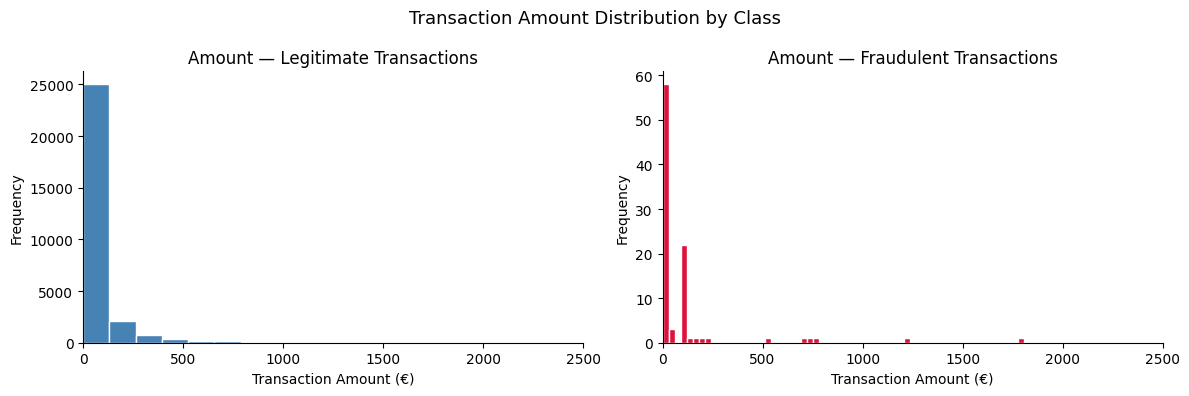

Average legitimate transaction: €78.55
Average fraudulent transaction: €96.61
Max legitimate amount: €7879.42
Max fraudulent amount: €1809.68


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(df[df['Class'] == 0]['Amount'],
             bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Amount — Legitimate Transactions')
axes[0].set_xlabel('Transaction Amount (€)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 2500)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


axes[1].hist(df[df['Class'] == 1]['Amount'],
             bins=60, color='crimson', edgecolor='white')
axes[1].set_title('Amount — Fraudulent Transactions')
axes[1].set_xlabel('Transaction Amount (€)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 2500)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Transaction Amount Distribution by Class', fontsize=13)
plt.tight_layout()
plt.savefig('amount_histogram.png', dpi=150)
plt.show()


print(f"Average legitimate transaction: €{df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Average fraudulent transaction: €{df[df['Class']==1]['Amount'].mean():.2f}")
print(f"Max legitimate amount: €{df[df['Class']==0]['Amount'].max():.2f}")
print(f"Max fraudulent amount: €{df[df['Class']==1]['Amount'].max():.2f}")

Correlation heatmap

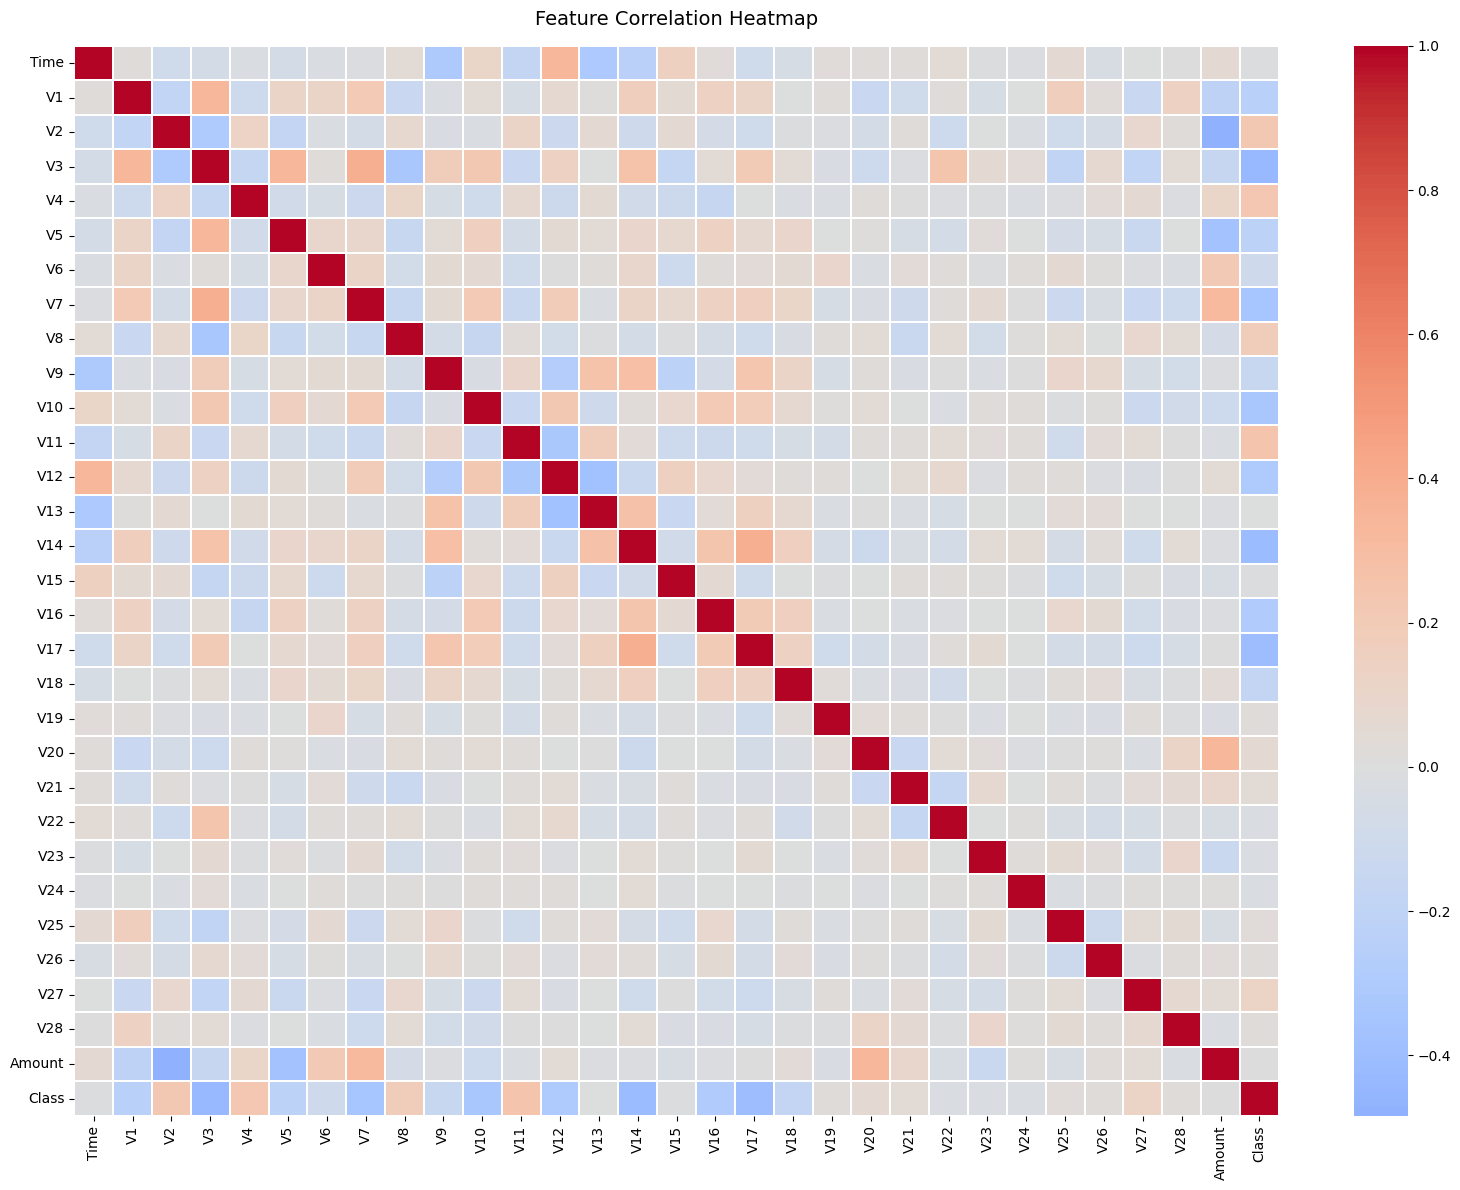

Top 10 features most correlated with fraud:
V3     0.432900
V14    0.408912
V17    0.404957
V7     0.343687
V10    0.328865
V12    0.301996
V16    0.292069
V11    0.256040
V1     0.243443
V4     0.233612
Name: Class, dtype: float64


In [14]:
plt.figure(figsize=(16, 12))

corr = df.corr()

sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            linewidths=0.3,
            annot=False)

plt.title('Feature Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# Print top features most correlated with fraud (Class)
print("Top 10 features most correlated with fraud:")
print(df.corr()['Class'].abs().sort_values(ascending=False)[1:11])

Boxplots for top fraud-discriminating features

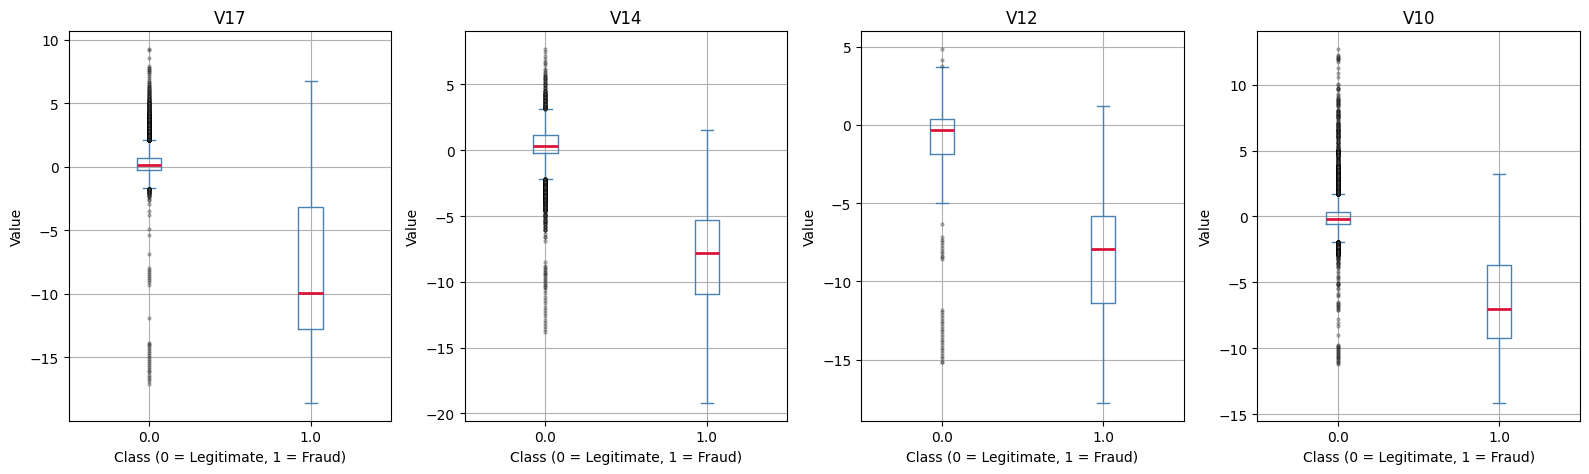

In [15]:
top_features = ['V17', 'V14', 'V12', 'V10']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, feat in enumerate(top_features):
    df.boxplot(column=feat, by='Class', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='crimson', linewidth=2),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'),
               flierprops=dict(marker='o', markersize=2,
                               markerfacecolor='gray', alpha=0.3))
    axes[i].set_title(f'{feat}', fontsize=12)
    axes[i].set_xlabel('Class (0 = Legitimate, 1 = Fraud)')
    axes[i].set_ylabel('Value')

plt.suptitle('Top Features — Fraud vs Legitimate Transactions',
             fontsize=13, y=1.02)
fig.suptitle('')  # removes the automatic 'Boxplot grouped by Class' title
plt.tight_layout()
plt.savefig('boxplots_key_features.png', dpi=150)
plt.show()

Transaction volume over time

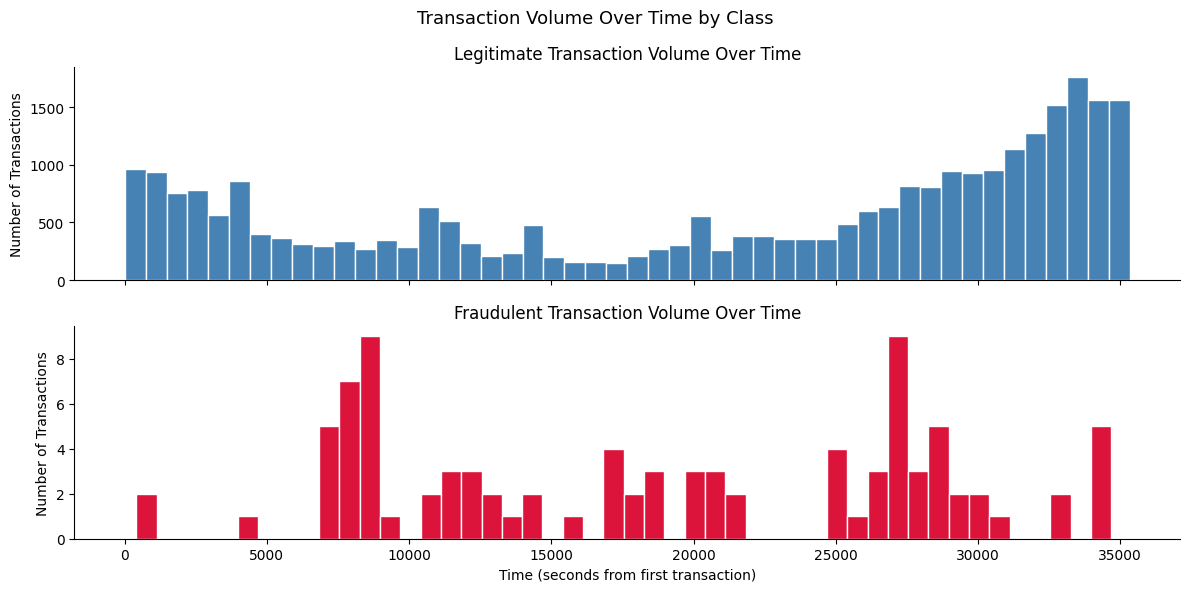

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].hist(df[df['Class'] == 0]['Time'],
             bins=48, color='steelblue', edgecolor='white')
axes[0].set_title('Legitimate Transaction Volume Over Time')
axes[0].set_ylabel('Number of Transactions')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(df[df['Class'] == 1]['Time'],
             bins=48, color='crimson', edgecolor='white')
axes[1].set_title('Fraudulent Transaction Volume Over Time')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xlabel('Time (seconds from first transaction)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Transaction Volume Over Time by Class', fontsize=13)
plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150)
plt.show()

Installing  and importing preprocessing libraries

In [17]:
!pip install imbalanced-learn -q

# Import preprocessing tools
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print()

Scale Amount and Time features

In [18]:
df_processed = df.copy()

In [19]:
scaler = StandardScaler()

df_processed['Amount_Scaled'] = scaler.fit_transform(
    df_processed['Amount'].values.reshape(-1, 1))

df_processed['Time_Scaled'] = scaler.fit_transform(
    df_processed['Time'].values.reshape(-1, 1))


df_processed = df_processed.drop(columns=['Amount', 'Time'])


print("Processed dataset shape:", df_processed.shape)
print("\nFirst 3 rows of scaled features:")
print(df_processed[['Amount_Scaled', 'Time_Scaled']].head(3))

print(f"\nAmount_Scaled — mean: {df_processed['Amount_Scaled'].mean():.4f}, "
      f"std: {df_processed['Amount_Scaled'].std():.4f}")
print(f"Time_Scaled   — mean: {df_processed['Time_Scaled'].mean():.4f}, "
      f"std: {df_processed['Time_Scaled'].std():.4f}")

Processed dataset shape: (29023, 31)

First 3 rows of scaled features:
   Amount_Scaled  Time_Scaled
0       0.323313    -1.761622
1      -0.345628    -1.761622
2       1.366084    -1.761539

Amount_Scaled — mean: 0.0000, std: 1.0000
Time_Scaled   — mean: 0.0000, std: 1.0000


Split data into training and test sets

In [20]:
X = df_processed.drop(columns=['Class'])
y = df_processed['Class']

In [22]:
nan_indices = y[y.isna()].index
X_cleaned = X.drop(nan_indices)
y_cleaned = y.drop(nan_indices)

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=y_cleaned)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)

print("\nTraining set class distribution:")
print(y_train.value_counts())

print("\nTest set class distribution:")
print(y_test.value_counts())

print(f"\nFraud in training set: {y_train.sum()} cases")
print(f"Fraud in test set:     {y_test.sum()} cases")

Training set size: (23217, 30)
Test set size:     (5805, 30)

Training set class distribution:
Class
0.0    23143
1.0       74
Name: count, dtype: int64

Test set class distribution:
Class
0.0    5786
1.0      19
Name: count, dtype: int64

Fraud in training set: 74.0 cases
Fraud in test set:     19.0 cases


Applying SMOTE to training set only

In [23]:
print("Before SMOTE:")
print(f"  Legitimate: {sum(y_train == 0)}")
print(f"  Fraud:      {sum(y_train == 1)}")
print(f"  Total:      {len(y_train)}")

Before SMOTE:
  Legitimate: 23143
  Fraud:      74
  Total:      23217


In [24]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Legitimate: {sum(y_train_smote == 0)}")
print(f"  Fraud:      {sum(y_train_smote == 1)}")
print(f"  Total:      {len(y_train_smote)}")

print(f"\nNew fraud ratio: "
      f"{sum(y_train_smote==1)/len(y_train_smote)*100:.1f}%")


After SMOTE:
  Legitimate: 23143
  Fraud:      23143
  Total:      46286

New fraud ratio: 50.0%


 creating a new feature

In [25]:
train_mean_amount = X_train['Amount_Scaled'].mean()


X_train_smote['Amount_to_Mean_Ratio'] = (
    X_train_smote['Amount_Scaled'] / (train_mean_amount + 1e-9))

X_test['Amount_to_Mean_Ratio'] = (
    X_test['Amount_Scaled'] / (train_mean_amount + 1e-9))

print("Feature engineering complete!")
print("New training shape:", X_train_smote.shape)
print("New test shape:    ", X_test.shape)
print(f"\nNew feature sample values (first 5):")
print(X_train_smote['Amount_to_Mean_Ratio'].head())

Feature engineering complete!
New training shape: (46286, 31)
New test shape:     (5805, 31)

New feature sample values (first 5):
0    46.147181
1    60.371048
2    56.325579
3    52.272020
4    40.135614
Name: Amount_to_Mean_Ratio, dtype: float64


Import model libraries

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score,
                             precision_score, recall_score)
import time
import warnings
warnings.filterwarnings('ignore')

print()

Train Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression
import time

print("Training Logistic Regression on balanced sample...")
start = time.time()

Training Logistic Regression on balanced sample...


In [32]:
X_lr = X_train_smote.copy()
X_lr['Class'] = y_train_smote.values

fraud_sample = X_lr[X_lr['Class']==1].sample(n=10000, random_state=42)
legit_sample = X_lr[X_lr['Class']==0].sample(n=10000, random_state=42)
lr_sample = pd.concat([fraud_sample, legit_sample]).sample(
    frac=1, random_state=42)

X_lr_train = lr_sample.drop(columns=['Class'])
y_lr_train = lr_sample['Class']


In [28]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced')

lr_model.fit(X_lr_train, y_lr_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    lr_model, X_lr_train, y_lr_train,
    cv=cv, scoring='f1')

end = time.time()

print(f"Training time: {end - start:.1f} seconds")
print(f"\nCross-validation F1 scores: {cv_scores.round(4)}")
print(f"Mean CV F1:  {cv_scores.mean():.4f}")
print(f"Std CV F1:   {cv_scores.std():.4f}")

# Evaluate on full test set
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

print(f"\nTest set results:")
print(f"  Precision: {precision_score(y_test, lr_preds):.4f}")
print(f"  Recall:    {recall_score(y_test, lr_preds):.4f}")
print(f"  F1 Score:  {f1_score(y_test, lr_preds):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, lr_probs):.4f}")

Training time: 42.5 seconds

Cross-validation F1 scores: [0.9876 0.9898 0.9915 0.99   0.9885]
Mean CV F1:  0.9895
Std CV F1:   0.0014

Test set results:
  Precision: 0.1978
  Recall:    0.9474
  F1 Score:  0.3273
  ROC-AUC:   0.9793


Train Random Forest

In [34]:
from sklearn.utils import resample

print("Creating balanced training sample...")

# Use same approach as Logistic Regression — 20k balanced sample
X_rf = X_train_smote.copy()
X_rf['Class'] = y_train_smote.values

fraud_s = X_rf[X_rf['Class']==1].sample(n=10000, random_state=42)
legit_s = X_rf[X_rf['Class']==0].sample(n=10000, random_state=42)
rf_sample = pd.concat([fraud_s, legit_s]).sample(frac=1, random_state=42)

X_rf_train = rf_sample.drop(columns=['Class'])
y_rf_train = rf_sample['Class']

print(f"Training sample size: {X_rf_train.shape}")
print(f"Class balance: {y_rf_train.value_counts().to_dict()}")

# Train Random Forest
print("\nTraining Random Forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1)

rf_model.fit(X_rf_train, y_rf_train)

end = time.time()
print(f"Training time: {end - start:.1f} seconds")

# Evaluate on full test set
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print(f"\nTest set results:")
print(f"  Precision: {precision_score(y_test, rf_preds):.4f}")
print(f"  Recall:    {recall_score(y_test, rf_preds):.4f}")
print(f"  F1 Score:  {f1_score(y_test, rf_preds):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, rf_probs):.4f}")

Creating balanced training sample...
Training sample size: (20000, 31)
Class balance: {0.0: 10000, 1.0: 10000}

Training Random Forest...
Training time: 8.8 seconds

Test set results:
  Precision: 0.8182
  Recall:    0.9474
  F1 Score:  0.8780
  ROC-AUC:   0.9553


Hyperparameter tuning

In [35]:
print("Testing 3 hyperparameter configurations...\n")

configs = [
    {'n_estimators': 50,  'max_depth': 8},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 15},
]

results = []

for cfg in configs:
    start = time.time()

    model = RandomForestClassifier(
        n_estimators=cfg['n_estimators'],
        max_depth=cfg['max_depth'],
        random_state=42,
        class_weight='balanced',
        n_jobs=-1)

    model.fit(X_rf_train, y_rf_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    f1  = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    pre = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    elapsed = time.time() - start

    results.append({**cfg, 'F1': f1, 'AUC': auc,
                    'Precision': pre, 'Recall': rec})

    print(f"n_estimators={cfg['n_estimators']}, "
          f"max_depth={cfg['max_depth']} | "
          f"F1={f1:.4f} | AUC={auc:.4f} | "
          f"Precision={pre:.4f} | Recall={rec:.4f} | "
          f"Time={elapsed:.1f}s")


best = max(results, key=lambda x: x['F1'])
print(f"\nBest configuration:")
print(f"  n_estimators={best['n_estimators']}, "
      f"max_depth={best['max_depth']}")
print(f"  F1={best['F1']:.4f} | AUC={best['AUC']:.4f}")
print(f"  Precision={best['Precision']:.4f} | "
      f"Recall={best['Recall']:.4f}")

Testing 3 hyperparameter configurations...

n_estimators=50, max_depth=8 | F1=0.8182 | AUC=0.9892 | Precision=0.7200 | Recall=0.9474 | Time=4.8s
n_estimators=100, max_depth=10 | F1=0.8780 | AUC=0.9553 | Precision=0.8182 | Recall=0.9474 | Time=7.2s
n_estimators=100, max_depth=15 | F1=0.9000 | AUC=0.9700 | Precision=0.8571 | Recall=0.9474 | Time=9.2s

Best configuration:
  n_estimators=100, max_depth=15
  F1=0.9000 | AUC=0.9700
  Precision=0.8571 | Recall=0.9474


Confusion Matrix

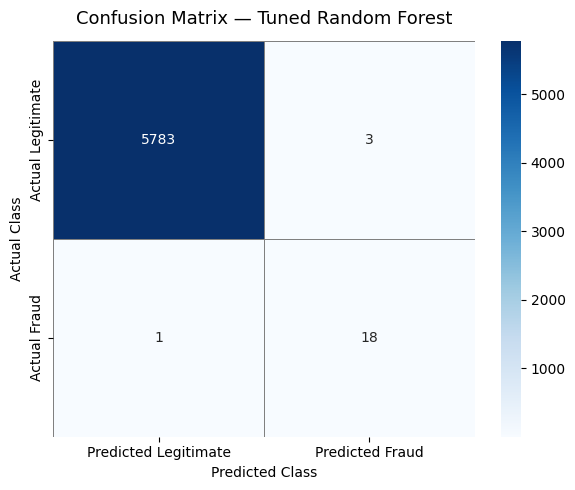

True Negatives  (Legit correctly cleared): 5,783
False Positives (Legit flagged as fraud):  3
False Negatives (Fraud missed):            1
True Positives  (Fraud correctly caught):  18

Fraud detection rate: 94.7%
False alarm rate:     0.05%


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


best_model = RandomForestClassifier(
    n_estimators=best['n_estimators'],
    max_depth=best['max_depth'],
    random_state=42,
    class_weight='balanced',
    n_jobs=-1)

best_model.fit(X_rf_train, y_rf_train)
best_preds = best_model.predict(X_test)
best_probs = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'],
            linewidths=0.5, linecolor='gray')

ax.set_title('Confusion Matrix — Tuned Random Forest',
             fontsize=13, pad=12)
ax.set_ylabel('Actual Class')
ax.set_xlabel('Predicted Class')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Legit correctly cleared): {tn:,}")
print(f"False Positives (Legit flagged as fraud):  {fp:,}")
print(f"False Negatives (Fraud missed):            {fn}")
print(f"True Positives  (Fraud correctly caught):  {tp}")
print(f"\nFraud detection rate: {tp/(tp+fn)*100:.1f}%")
print(f"False alarm rate:     {fp/(fp+tn)*100:.2f}%")

ROC Curve

In [37]:
best_preds = rf_model.predict(X_test)
best_probs = rf_model.predict_proba(X_test)[:, 1]

print("Predictions regenerated successfully!")
print(f"Test samples: {len(best_probs)}")

Predictions regenerated successfully!
Test samples: 5805


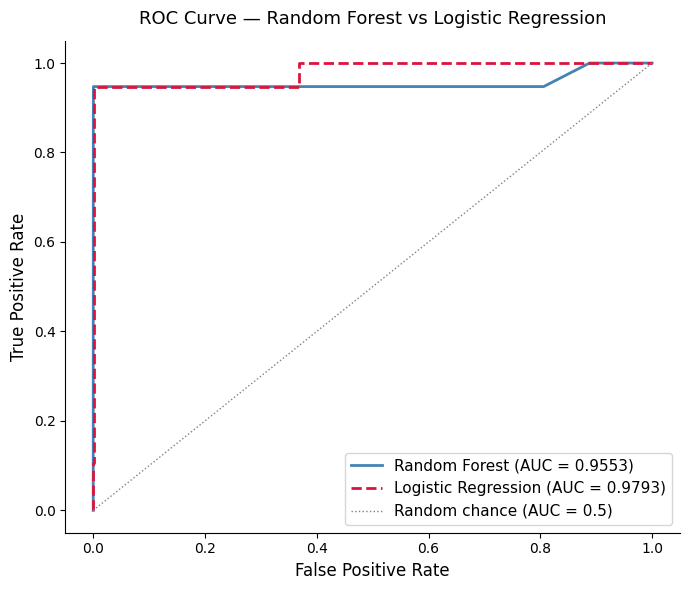

Random Forest AUC:      0.9553
Logistic Regression AUC: 0.9793


In [38]:
from sklearn.metrics import roc_curve, auc


fpr_rf, tpr_rf, _ = roc_curve(y_test, best_probs)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)

auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)

fig, ax = plt.subplots(figsize=(7, 6))


ax.plot(fpr_rf, tpr_rf, color='steelblue', linewidth=2,
        label=f'Random Forest (AUC = {auc_rf:.4f})')
ax.plot(fpr_lr, tpr_lr, color='crimson', linewidth=2,
        linestyle='--',
        label=f'Logistic Regression (AUC = {auc_lr:.4f})')


ax.plot([0, 1], [0, 1], color='gray', linewidth=1,
        linestyle=':', label='Random chance (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Random Forest vs Logistic Regression',
             fontsize=13, pad=12)
ax.legend(loc='lower right', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f"Random Forest AUC:      {auc_rf:.4f}")
print(f"Logistic Regression AUC: {auc_lr:.4f}")

In [39]:
import pandas as pd

In [40]:
importances = rf_model.feature_importances_
feature_names = X_test.columns.tolist()


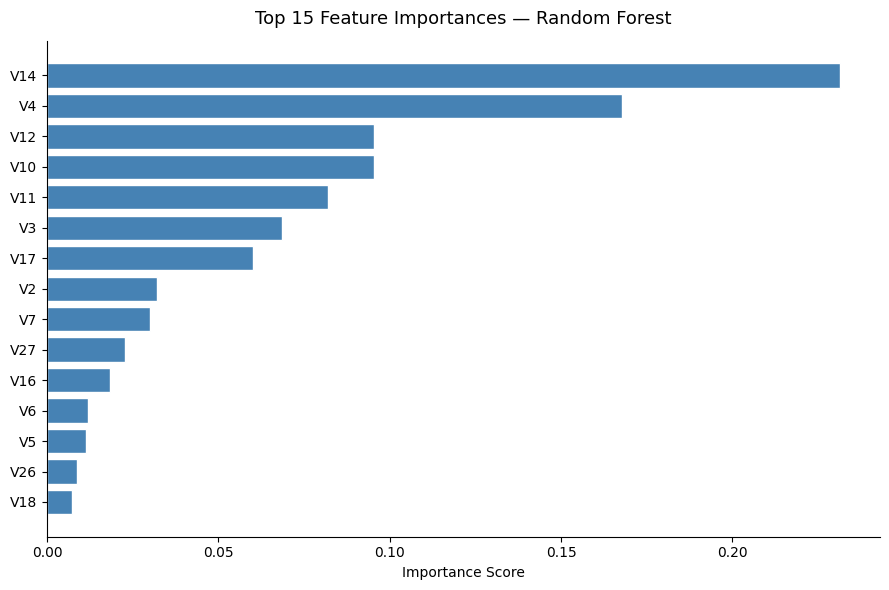

Top 10 most important features:
Feature  Importance
    V14    0.231498
     V4    0.167789
    V12    0.095440
    V10    0.095392
    V11    0.081874
     V3    0.068523
    V17    0.060214
     V2    0.032030
     V7    0.030207
    V27    0.022823


In [41]:
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(feat_df['Feature'][::-1],
        feat_df['Importance'][::-1],
        color='steelblue', edgecolor='white')

ax.set_title('Top 15 Feature Importances — Random Forest',
             fontsize=13, pad=12)
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# Print top 10
print("Top 10 most important features:")
print(feat_df.head(10).to_string(index=False))